In [1]:
%reset -f
M3Dsynth_dir = '/mnt/lguarnera_group/opontorno/med_datasets/M3DSynth' # insert the correct path
from config import DATA_DIR
import pandas as pd
import os
import os
import numpy as np
import matplotlib.pyplot as plt
from medforensics.utils.tiff_utils import load_tiff_scan, load_slice_tiff_scan, get_shape_tiff_scan
from medforensics.utils.tiff_utils import get_percentile_tiff_scan, apply_percentile

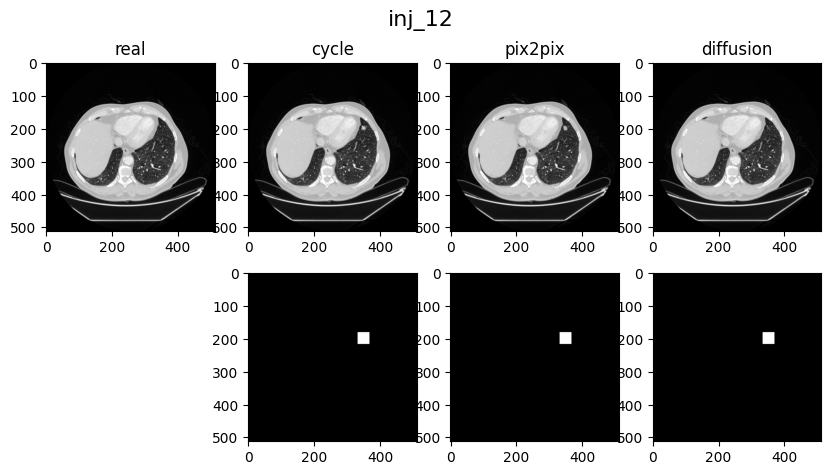

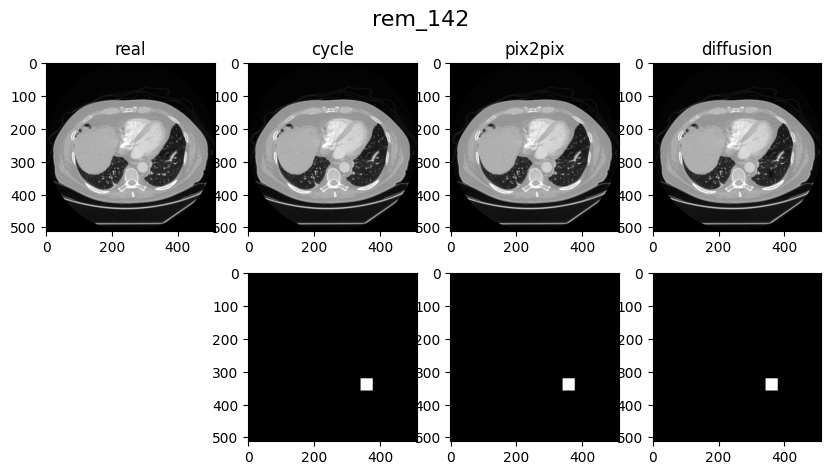

In [5]:

list_mod = ['real', 'cycle', 'pix2pix', 'diffusion']
list_img = [('inj_12', 183), ('rem_142', 160)]

for img, slide in list_img:
    fig = plt.figure(figsize=(10,5))
    for ind, mod in enumerate(list_mod):
        scan_directory = os.path.join(M3Dsynth_dir, mod, 'scan', img)
        shape = get_shape_tiff_scan(scan_directory)
        
        scan = load_slice_tiff_scan(scan_directory, shape, np.uint16, slide, slide+1)[0]
        low, high = get_percentile_tiff_scan(scan_directory, np.uint16)
        scan = apply_percentile(scan, low, high)
        plt.subplot(2,len(list_mod),ind+1)
        plt.imshow(scan, cmap='gray', clim=[0,1])
        plt.title(mod)
        
        if mod!='real':
            mask_directory = os.path.join(M3Dsynth_dir, mod, 'label', img)
            mask = load_slice_tiff_scan(mask_directory, shape, np.bool_, slide, slide+1)[0]
            plt.subplot(2,len(list_mod),ind+5)
            plt.imshow(mask, cmap='gray', clim=[0,1])
    
    fig.suptitle(img, fontsize=16)
    plt.show()

In [ ]:
import glob
import tifffile as tiff
import numpy as np

files = sorted(glob.glob("/mnt/lguarnera_group/opontorno/med_datasets/M3DSynth/real/scan/inj_1/slide*.tiff"))

slices = [tiff.imread(f) for f in files]
volume = np.stack(slices, axis=0)

print(volume.shape)

(241, 512, 512)


In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact

def show_slice(z):
    plt.figure(figsize=(6,6))
    if volume.ndim == 3:
        plt.imshow(volume[z], cmap="gray")
    else:
        plt.imshow(volume[z])
    plt.title(f"Slice {z}")
    plt.axis("off")
    plt.show()

interact(show_slice, z=(0, volume.shape[0]-1))

In [ ]:
import napari

viewer = napari.Viewer()
viewer.add_image(volume)
napari.run()

In [12]:
tab = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))
sets = pd.read_csv(os.path.join(DATA_DIR, 'sets.csv'))
centers = pd.read_csv(os.path.join(DATA_DIR, 'centers.csv'))
lidc = pd.read_csv(os.path.join(DATA_DIR, 'LIDC.csv'))

print(tab)
print(sets)
print(centers)
print(lidc)

         img_id   ty    mod         orig_id  sdir_id  coord_z  coord_y  \
0         rem_1  rem   real  LIDC-IDRI-0003  3000611       57      198   
1        rem_10  rem   real  LIDC-IDRI-0014  3000562       40      276   
2       rem_100  rem   real  LIDC-IDRI-0124        3       48      287   
3      rem_1000  rem   real  LIDC-IDRI-0884        2       54      248   
4      rem_1001  rem   real  LIDC-IDRI-0886    30036       33      185   
...         ...  ...    ...             ...      ...      ...      ...   
11823   inj_995  inj  cycle  LIDC-IDRI-0530    30889       53      321   
11824   inj_996  inj  cycle  LIDC-IDRI-0532  3000679       91      419   
11825   inj_997  inj  cycle  LIDC-IDRI-0534     5473       46      382   
11826   inj_998  inj  cycle  LIDC-IDRI-0535    30033      102      325   
11827   inj_999  inj  cycle  LIDC-IDRI-0535    30033      158      323   

       coord_x  
0          308  
1          357  
2          393  
3          375  
4          265  
...      

In [45]:
tab2 = tab.merge(sets, on='orig_id')
print(tab2)
print(tab2.groupby('orig_id').first().reset_index()['set'].value_counts())

         img_id   ty    mod         orig_id  sdir_id  coord_z  coord_y  \
0         rem_1  rem   real  LIDC-IDRI-0003  3000611       57      198   
1        rem_10  rem   real  LIDC-IDRI-0014  3000562       40      276   
2       rem_100  rem   real  LIDC-IDRI-0124        3       48      287   
3      rem_1000  rem   real  LIDC-IDRI-0884        2       54      248   
4      rem_1001  rem   real  LIDC-IDRI-0886    30036       33      185   
...         ...  ...    ...             ...      ...      ...      ...   
11823   inj_995  inj  cycle  LIDC-IDRI-0530    30889       53      321   
11824   inj_996  inj  cycle  LIDC-IDRI-0532  3000679       91      419   
11825   inj_997  inj  cycle  LIDC-IDRI-0534     5473       46      382   
11826   inj_998  inj  cycle  LIDC-IDRI-0535    30033      102      325   
11827   inj_999  inj  cycle  LIDC-IDRI-0535    30033      158      323   

       coord_x    set  
0          308  train  
1          357  train  
2          393  train  
3          375 

In [ ]:
tab3 = tab2.merge(centers,  how='left')
print(tab3)
print(tab3.groupby('orig_id').first().reset_index()['set'].value_counts())

         img_id   ty    mod         orig_id  sdir_id  coord_z  coord_y  \
0         rem_1  rem   real  LIDC-IDRI-0003  3000611       57      198   
1        rem_10  rem   real  LIDC-IDRI-0014  3000562       40      276   
2       rem_100  rem   real  LIDC-IDRI-0124        3       48      287   
3      rem_1000  rem   real  LIDC-IDRI-0884        2       54      248   
4      rem_1001  rem   real  LIDC-IDRI-0886    30036       33      185   
...         ...  ...    ...             ...      ...      ...      ...   
11823   inj_995  inj  cycle  LIDC-IDRI-0530    30889       53      321   
11824   inj_996  inj  cycle  LIDC-IDRI-0532  3000679       91      419   
11825   inj_997  inj  cycle  LIDC-IDRI-0534     5473       46      382   
11826   inj_998  inj  cycle  LIDC-IDRI-0535    30033      102      325   
11827   inj_999  inj  cycle  LIDC-IDRI-0535    30033      158      323   

       coord_x    set  center_test_z  center_test_y  center_test_x  
0          308  train            NaN      

In [44]:
tab3_real = tab3[tab3['set']=='test']
tab3_real

,img_id,ty,mod_x,orig_id,sdir_id,coord_z,coord_y,coord_x,set,mod_y,center_test_z,center_test_y,center_test_x
210,rem_287,rem,real,LIDC-IDRI-0440,32130,156,156,304,test,real,153.0,256.0,256.0
211,rem_287,rem,real,LIDC-IDRI-0440,32130,156,156,304,test,pix2pix,162.0,256.0,256.0
212,rem_287,rem,real,LIDC-IDRI-0440,32130,156,156,304,test,diffusion,149.0,256.0,256.0
213,rem_287,rem,real,LIDC-IDRI-0440,32130,156,156,304,test,cycle,168.0,256.0,256.0
214,rem_288,rem,real,LIDC-IDRI-0447,2,93,285,426,test,real,94.0,256.0,256.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19487,inj_998,inj,cycle,LIDC-IDRI-0535,30033,102,325,393,test,cycle,94.0,256.0,256.0
19488,inj_999,inj,cycle,LIDC-IDRI-0535,30033,158,323,129,test,real,160.0,256.0,256.0
19489,inj_999,inj,cycle,LIDC-IDRI-0535,30033,158,323,129,test,pix2pix,166.0,256.0,256.0
19490,inj_999,inj,cycle,LIDC-IDRI-0535,30033,158,323,129,test,diffusion,167.0,256.0,256.0
